<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK12/RNN_LSTM(TSLA_csv_%EC%82%AC%EC%9A%A9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# (1) 필요한 라이브러리 모듈을 포함시킨다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
# (2) TSLA.csv 파일을 불러온다.

path = '/content/drive/MyDrive/Colab Notebooks/WEEK12/TSLA.csv'
df = pd.read_csv(path)

print(df.head())

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500


In [ ]:
# (3) 사용하지 않을 컬럼을 제거한다.
# Date, High, Low, Adj Close, Volume 데이터를 날린다.

df = df.drop(['Date', 'High', 'Low', 'Adj Close', 'Volume'], axis=1)

In [ ]:
# (4) Open 데이터와 Close 데이터를 각각 분리한다.

open_values = df[['Open']].values
close_values = df[['Close']].values

In [ ]:
# (5) 특징값 정규화를 수행한다.
# 신경망 입력값은 0~1 사이 값으로 변환하는 것이 좋다.

open_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_open = open_scaler.fit_transform(open_values)
scaled_close = close_scaler.fit_transform(close_values)

In [ ]:
# (6) 훈련 데이터와 테스트 데이터를 분리한다.
# 테스트 데이터는 후반부 500개로 한다.

TEST_SIZE = 500

train_open = scaled_open[:-TEST_SIZE]
train_close = scaled_close[:-TEST_SIZE]

test_open = scaled_open[-TEST_SIZE:]
test_close = scaled_close[-TEST_SIZE:]

In [ ]:
# (7) 순차 훈련 데이터를 생성한다.
# window 크기만큼 Open 데이터를 묶고, 그 다음 Close 값을 정답으로 사용한다.

def make_sample(data, target, window):
    train = []
    label = []

    for i in range(len(data) - window):
        train.append(data[i:i + window])
        label.append(target[i + window])

    return np.array(train), np.array(label)

In [ ]:
# (8) window size를 3으로 설정한다.

window_size = 3

X_train, y_train = make_sample(train_open, train_close, window_size)
X_test, y_test = make_sample(test_open, test_close, window_size)

In [ ]:
# (9) LSTM 모델을 정의한다.

model = Sequential()

model.add(
    LSTM(
        16,
        input_shape=(X_train.shape[1], 1),
        activation='tanh',
        return_sequences=False
    )
)

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# (10) 모델을 컴파일한다.

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
# (11) LSTM 모델을 학습시킨다.

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.7816e-04
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3493e-05
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.5545e-06
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8530e-06
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4808e-06
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8048e-06
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4580e-06
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1275e-06
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9986e-06
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8906e-06
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0017e-06
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9568e-06
Epoch 13/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.5573e-06
Epoch 14/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss

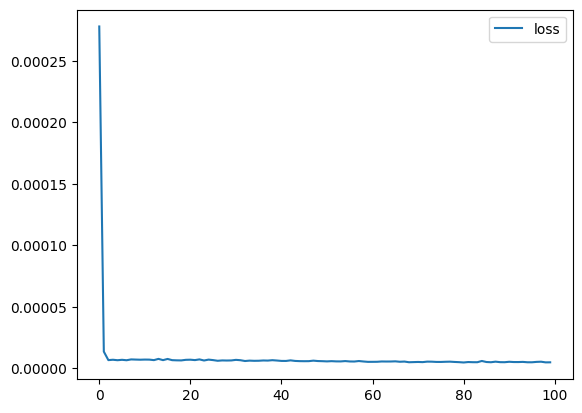

In [ ]:
# (12) 손실 함수 그래프를 출력한다.

plt.plot(history.history['loss'], label='loss')
plt.legend()
plt.show()

In [ ]:
# (13) 테스트셋을 이용하여 Close 값을 예측한다.

pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
# (14) 정규화된 값을 원래 주가 단위로 복원한다.

pred_original = close_scaler.inverse_transform(pred)
y_test_original = close_scaler.inverse_transform(y_test)

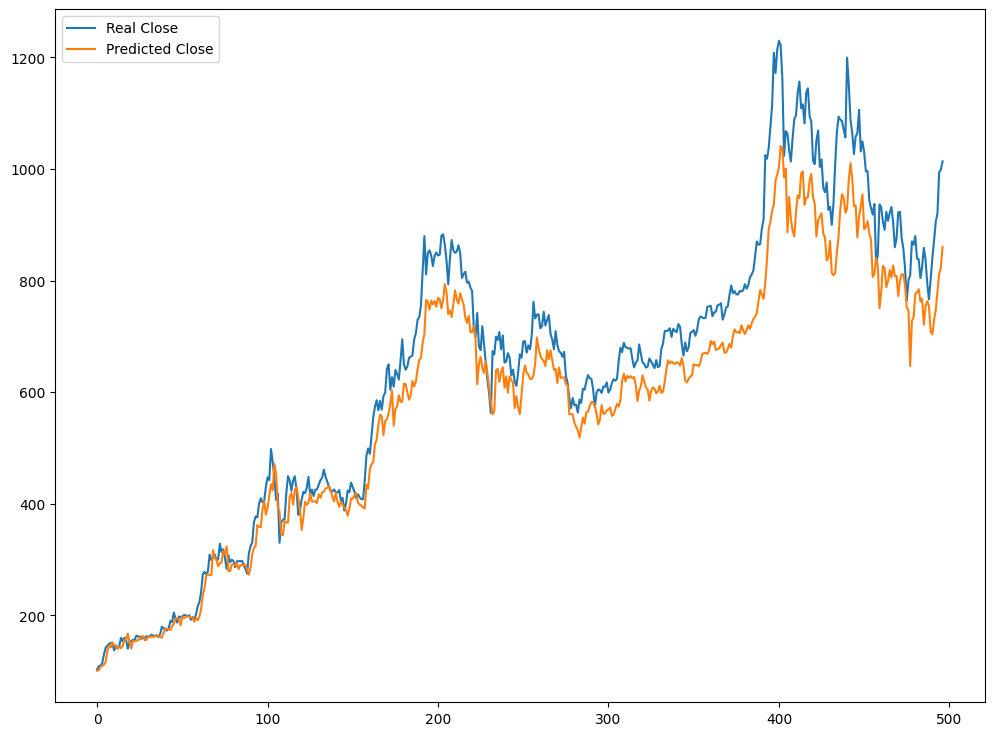

In [ ]:
# (15) 실제 Close 값과 예측 Close 값을 그래프로 비교한다.

plt.figure(figsize=(12, 9))
plt.plot(y_test_original, label='Real Close')
plt.plot(pred_original, label='Predicted Close')
plt.legend()
plt.show()